In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

# MRS - Klasifikacija EEG podatkov pred in po zaužitju kave

## 1. Uvod

**Problem**, ki ga bom obravnaval v tem projektu, je **binarna klasifikacija** EEG podatkov na pred in po zaužitju kave.

**Cilj** je doseči čim večjo preciznost pri klasifikaciji EEG podatkov na pred in po zaužitju kave.

**Načrt postopka rešitve** vključuje naslednje korake:
1. **Deskriptivna statistika**: Pregled in grafični prikaz osnovnih značilnosti podatkov.
2. **Razdelitev podatkov**: Podatke bom razdelil na učni in testni sklop, da bom lahko preveril učinkovitost modela.
3. **Izbira modela**: Uporabljeni bodo različni algoritmi za klasifikacijo.
4. **Učenje modela**: Učenje modela na učni in testni množici.
5. **Evalvacija modela**: Vrednotenje uspešnosti modela bo izvedeno z uporabo kazalnikov, kot so točnost, preciznost, priklic in F1-ocena.
6. **Optimizacija modela**: Optimizacija hiperparametrov, če bo potrebna.
7. **Primerjava modelov**: Primerjava uspešnosti modelov.

## 2. Opis podatkov

Podatke so shranjeni v strukturi **ALLEEG**, ki je uporabljena za organizacijo več EEG datasetov (podatkov več udeležencev) in njihovo obdelavo v enem samem okolju (Slika 3). Ta struktura je del dokumentacije **EEGLABa**.

**ALLEEG** zajema veliko podatkov, najpomembnejši za nas so:

- **subject**: šifra udeleženca
- **condition/group**: eksperimentalni pogoj/eksperimentalna skupina
- **trials**: število epoh
- **pnts**: število podatkovnih točk pri vsaki epohi
- **srate**: predstavlja frekvenco vzorčenja. Recimo, da smo pri zajemu podatkov frekvenco vzorčenja nastavili na 500 Hz. To pomeni, da smo zajeli 500 podatkovnih točk na sekundo, ali drugače, eno podatkovno točko na 2 milisekundi.
- **xmin**: začetek epohe. Npr. -0.1000 pomeni, da se epoha začne 100 ms pred markerjem.
- **xmax**: konec epohe. Npr. 1.998 pomeni, da se epoha konča 1998 ms po markerju (približno 2 sekundi).
- **data**: podatki v 3D formatu `[število elektrod × število podatkovnih točk v posamezni epohi × število epoh]` (npr. 32 elektrod × 1260 podatkovnih točk × 100 epoh). To omogoča dostop do časovnih serij za vsako elektrodo in epoho.
- **chanlocs**: imena in lokacije elektrod
- **event**: Vsebuje informacije o markerjih (tip eksperimentalnega pogoja, latenca,...). Te oznake so ključne za povezavo posameznih epoh s specifičnimi eksperimentalnimi pogoji.
- **epoch**: Vsebuje informacije o posameznih epohah, vključno z eksperimentalnim pogojem in drugimi podatki (npr. identifikacijsko številko dogodka, ki je epohi pripisana).

In [2]:
# Naloži .mat datoteko
data = loadmat("../data/raw/Caffeine_data_20250311.mat")

# Pregledovanje ključev
print(data.keys())

ALLEEG = data['ALLEEG']
print(ALLEEG[0, 0].dtype.names)  # Vsa polja v ALEEG

dict_keys(['__header__', '__version__', '__globals__', 'ALLEEG'])
('setname', 'filename', 'filepath', 'subject', 'group', 'condition', 'session', 'comments', 'nbchan', 'trials', 'pnts', 'srate', 'xmin', 'xmax', 'times', 'data', 'icaact', 'icawinv', 'icasphere', 'icaweights', 'icachansind', 'chanlocs', 'urchanlocs', 'chaninfo', 'ref', 'event', 'urevent', 'eventdescription', 'epoch', 'epochdescription', 'reject', 'stats', 'specdata', 'specicaact', 'splinefile', 'icasplinefile', 'dipfit', 'history', 'saved', 'etc', 'run', 'datfile', 'roi')


In [3]:
# Pregled subjektov
raw_data = {}
for i in range(ALLEEG.size):
    subject = ALLEEG[0, i]['subject'][0]
    condition = ALLEEG[0, i]['condition'][0]
    srate = ALLEEG[0, i]['srate'][0][0]
    data = ALLEEG[0, i]['data']
    group = ALLEEG[0, i]['group'][0]

    raw_data[(subject, condition)] = data
    print(i + 1, f"Subject: {subject}, Group: {group}, Condition: {condition}, Sampling Rate: {srate}, Data Shape: {data.shape}") # (electrodes, timepoints, epochs)

1 Subject: 311, Group: Caffeine, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 100)
2 Subject: 311, Group: Caffeine, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 100)
3 Subject: 315, Group: Caffeine, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 99)
4 Subject: 315, Group: Caffeine, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 100)
5 Subject: 318, Group: Placebo, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 100)
6 Subject: 318, Group: Placebo, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 100)
7 Subject: 340, Group: Caffeine, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 100)
8 Subject: 340, Group: Caffeine, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 100)
9 Subject: 342, Group: Caffeine, Condition: After, Sampling Rate: 600, Data Shape: (32, 900, 100)
10 Subject: 342, Group: Caffeine, Condition: Before, Sampling Rate: 600, Data Shape: (32, 900, 96)
11 Subject: 346, G

In [4]:
for i in range(ALLEEG.size):
    eeg = ALLEEG[0, i]

    subject = eeg['subject'][0]
    condition = eeg['condition'][0]
    group = eeg['group'][0] if 'group' in eeg.dtype.names else "N/A"

    srate = eeg['srate'][0][0]
    trials = eeg['trials'][0][0]
    pnts = eeg['pnts'][0][0]

    xmin = eeg['xmin'][0][0]
    xmax = eeg['xmax'][0][0]

    data = eeg['data']
    n_channels = data.shape[0]

    # imena elektrod
    chanlocs = eeg['chanlocs']
    channel_names = [chanlocs[0][j]['labels'][0] for j in range(len(chanlocs[0]))]

    print(f"\n--- Dataset {i+1} ---")
    print(f"Subject: {subject}")
    print(f"Condition: {condition} | Group: {group}")
    print(f"Channels: {n_channels} ({channel_names[:5]} ...)")
    print(f"Epochs (trials): {trials}")
    print(f"Timepoints per epoch: {pnts}")
    print(f"Sampling rate: {srate} Hz")
    print(f"Epoch duration: {xmin:.3f}s → {xmax:.3f}s ({xmax - xmin:.2f}s)")
    print(f"Data shape: {data.shape}")


--- Dataset 1 ---
Subject: 311
Condition: After | Group: Caffeine
Channels: 32 ([np.str_('Fp1'), np.str_('Fp2'), np.str_('AF3'), np.str_('AF4'), np.str_('F7')] ...)
Epochs (trials): 100
Timepoints per epoch: 1260
Sampling rate: 600 Hz
Epoch duration: -0.100s → 1.998s (2.10s)
Data shape: (32, 900, 100)

--- Dataset 2 ---
Subject: 311
Condition: Before | Group: Caffeine
Channels: 32 ([np.str_('Fp1'), np.str_('Fp2'), np.str_('AF3'), np.str_('AF4'), np.str_('F7')] ...)
Epochs (trials): 100
Timepoints per epoch: 1260
Sampling rate: 600 Hz
Epoch duration: -0.100s → 1.998s (2.10s)
Data shape: (32, 900, 100)

--- Dataset 3 ---
Subject: 315
Condition: After | Group: Caffeine
Channels: 32 ([np.str_('Fp1'), np.str_('Fp2'), np.str_('AF3'), np.str_('AF4'), np.str_('F7')] ...)
Epochs (trials): 99
Timepoints per epoch: 1260
Sampling rate: 600 Hz
Epoch duration: -0.100s → 1.998s (2.10s)
Data shape: (32, 900, 99)

--- Dataset 4 ---
Subject: 315
Condition: Before | Group: Caffeine
Channels: 32 ([np.str

In [5]:
n_timepoints = data.shape[1]
duration_from_data = n_timepoints / srate

duration_from_meta = xmax - xmin

print(f"Duration from data: {duration_from_data:.2f} s")
print(f"Duration from metadata: {duration_from_meta:.2f} s")

Duration from data: 1.50 s
Duration from metadata: 2.10 s


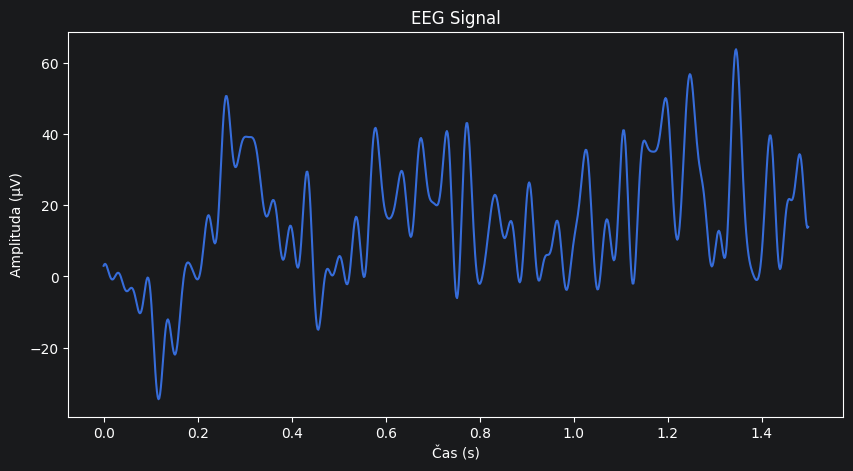

In [6]:
# Elektroda 1
channel_idx = 0  #
epoch_idx = 0
signal = ALLEEG[0, 0]['data'][channel_idx, :, epoch_idx]
time = np.arange(signal.shape[0]) / 600

plt.figure(figsize=(10, 5))
plt.plot(time, signal)
plt.title(f"EEG Signal")
plt.xlabel("Čas (s)")
plt.ylabel("Amplituda (μV)")
plt.show()

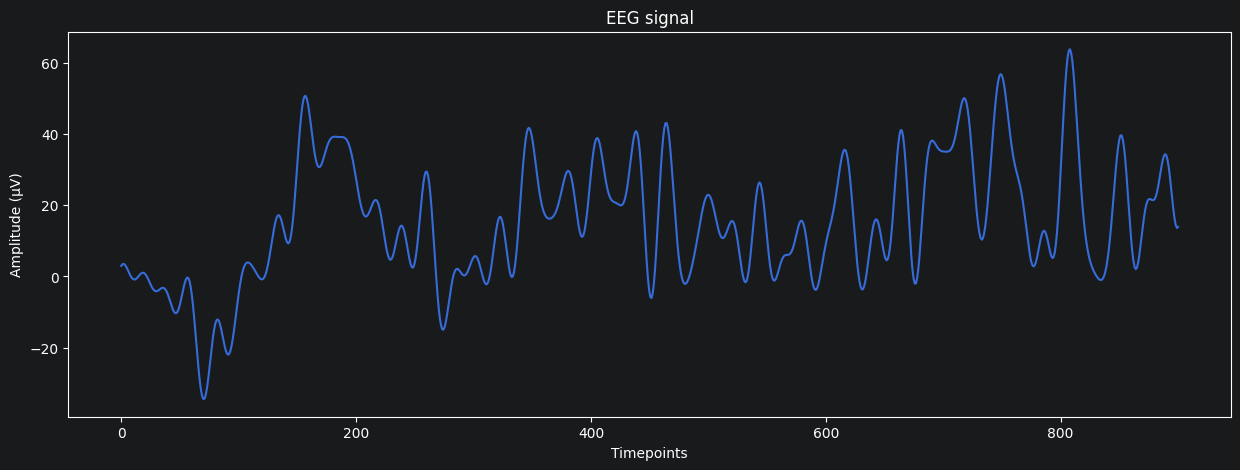

In [7]:
# Elektroda 1
channel_idx = 0

signal = ALLEEG[0,0]['data'][channel_idx,:,0]  # one epoch

n_times = signal.shape[0]

timepoints = np.linspace(0, 900, n_times)

plt.figure(figsize=(15,5))
plt.plot(timepoints, signal)
plt.xlabel("Timepoints")
plt.ylabel("Amplitude (µV)")
plt.title("EEG signal")
plt.show()

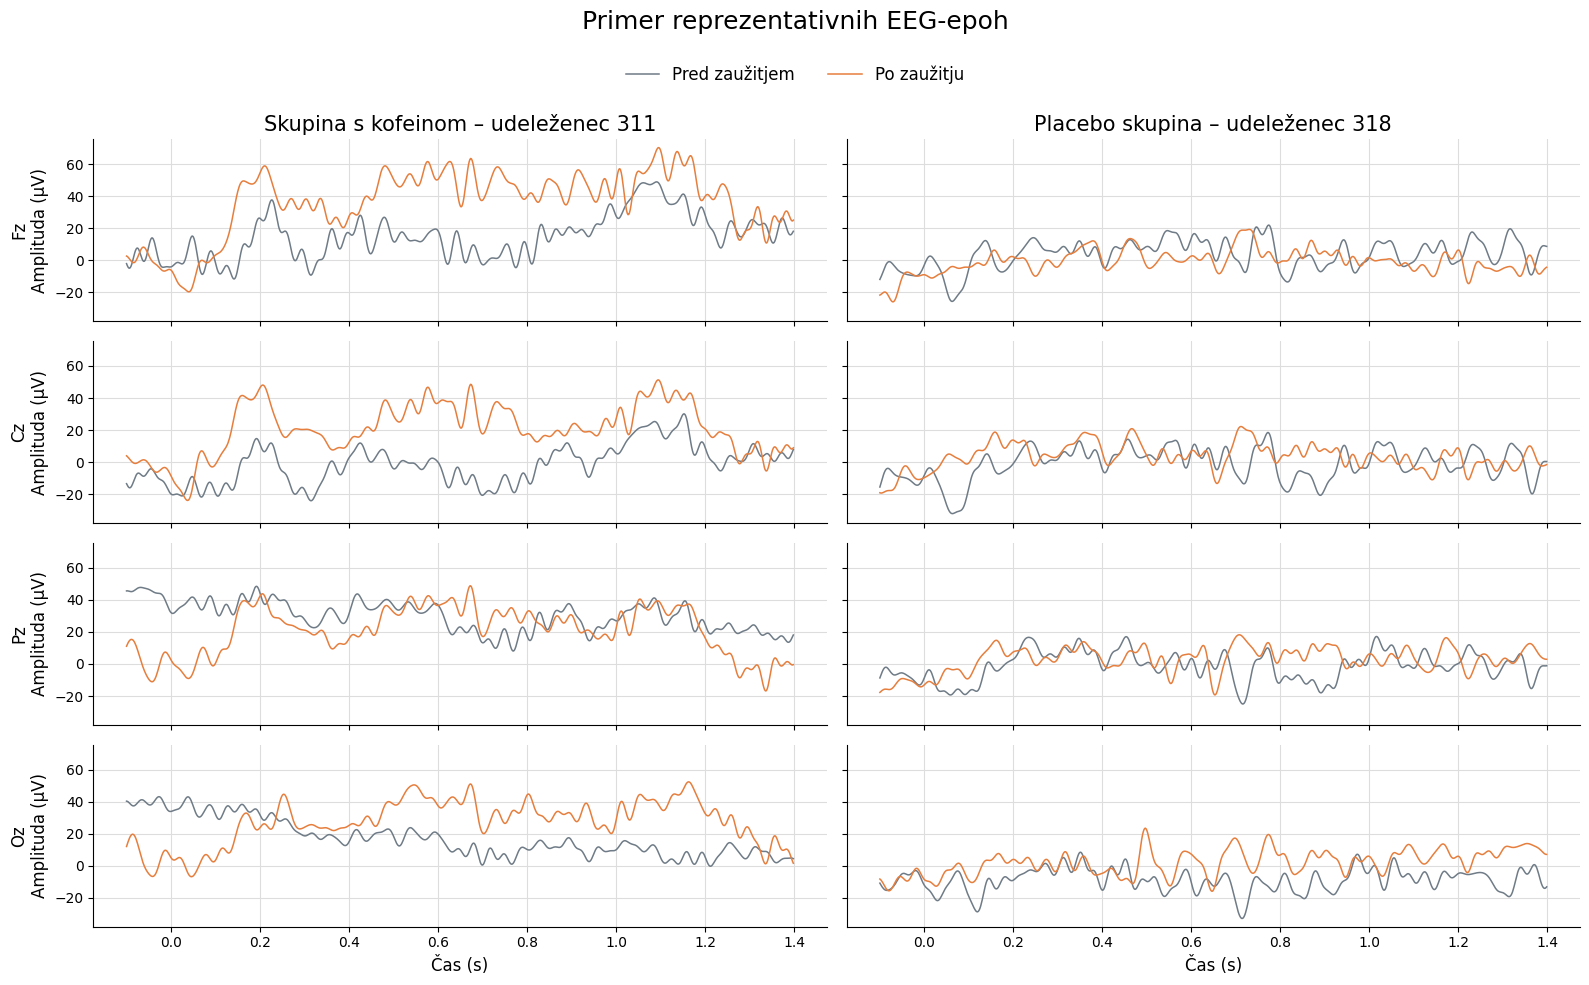

In [8]:
plt.style.use("default")

def get_text(eeg, field_name):
    value = np.squeeze(eeg[field_name])
    while isinstance(value, np.ndarray) and value.size == 1:
        value = value.item()
    return str(value).strip()

def find_eeg(ALLEEG, group_name, subject_id, condition_name):
    for i in range(ALLEEG.size):
        eeg = ALLEEG[0, i]

        group = get_text(eeg, "group")
        subject = get_text(eeg, "subject")
        condition = get_text(eeg, "condition")

        if group == group_name and subject == str(subject_id) and condition == condition_name:
            return eeg

    raise ValueError(
        f"Zapis ni najden: skupina={group_name}, "
        f"udeleženec={subject_id}, pogoj={condition_name}"
    )

# Nastavitve prikaza
epoch_idx = 0
channels_to_plot = ["Fz", "Cz", "Pz", "Oz"]

caffeine_subject = "311"
placebo_subject = "318"

# Pridobitev zapisov pred in po zaužitju
caffeine_before = find_eeg(ALLEEG, "Caffeine", caffeine_subject, "Before")
caffeine_after = find_eeg(ALLEEG, "Caffeine", caffeine_subject, "After")

placebo_before = find_eeg(ALLEEG, "Placebo", placebo_subject, "Before")
placebo_after = find_eeg(ALLEEG, "Placebo", placebo_subject, "After")

# Časovna os
srate = float(np.squeeze(caffeine_before["srate"]))
xmin = float(np.squeeze(caffeine_before["xmin"]))
n_timepoints = caffeine_before["data"].shape[1]
time = xmin + np.arange(n_timepoints) / srate

# Imena kanalov in njihovi indeksi
chanlocs = caffeine_before["chanlocs"][0]
channel_names = [get_text(chanlocs[i], "labels") for i in range(len(chanlocs))]
channel_indices = [channel_names.index(channel) for channel in channels_to_plot]

# Barve
before_color = "#6f7b86"
after_color = "#e67e3d"

# Bela podlaga slike in grafov
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 10),
    sharex=True,
    sharey=True,
    facecolor="white"
)

fig.suptitle("Primer reprezentativnih EEG-epoh", fontsize=18, y=0.98)

column_data = [
    (
        caffeine_before,
        caffeine_after,
        f"Skupina s kofeinom – udeleženec {caffeine_subject}"
    ),
    (
        placebo_before,
        placebo_after,
        f"Placebo skupina – udeleženec {placebo_subject}"
    )
]

for col_idx, (before_eeg, after_eeg, title) in enumerate(column_data):
    axes[0, col_idx].set_title(title, fontsize=15)

    for row_idx, (channel_name, channel_idx) in enumerate(
        zip(channels_to_plot, channel_indices)
    ):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor("white")

        before_signal = before_eeg["data"][channel_idx, :, epoch_idx]
        after_signal = after_eeg["data"][channel_idx, :, epoch_idx]

        ax.plot(
            time,
            before_signal,
            color=before_color,
            linewidth=1.1,
            label="Pred zaužitjem"
        )

        ax.plot(
            time,
            after_signal,
            color=after_color,
            linewidth=1.1,
            label="Po zaužitju"
        )

        ax.grid(True, color="#dddddd", linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if col_idx == 0:
            ax.set_ylabel(f"{channel_name}\nAmplituda (µV)", fontsize=12)

        if row_idx == len(channels_to_plot) - 1:
            ax.set_xlabel("Čas (s)", fontsize=12)

# Skupna legenda
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94),
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# Shranjevanje belega grafa brez prosojnega ali črnega ozadja
plt.savefig(
    "reprezentativne_eeg_epohe.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    transparent=False
)

plt.show()

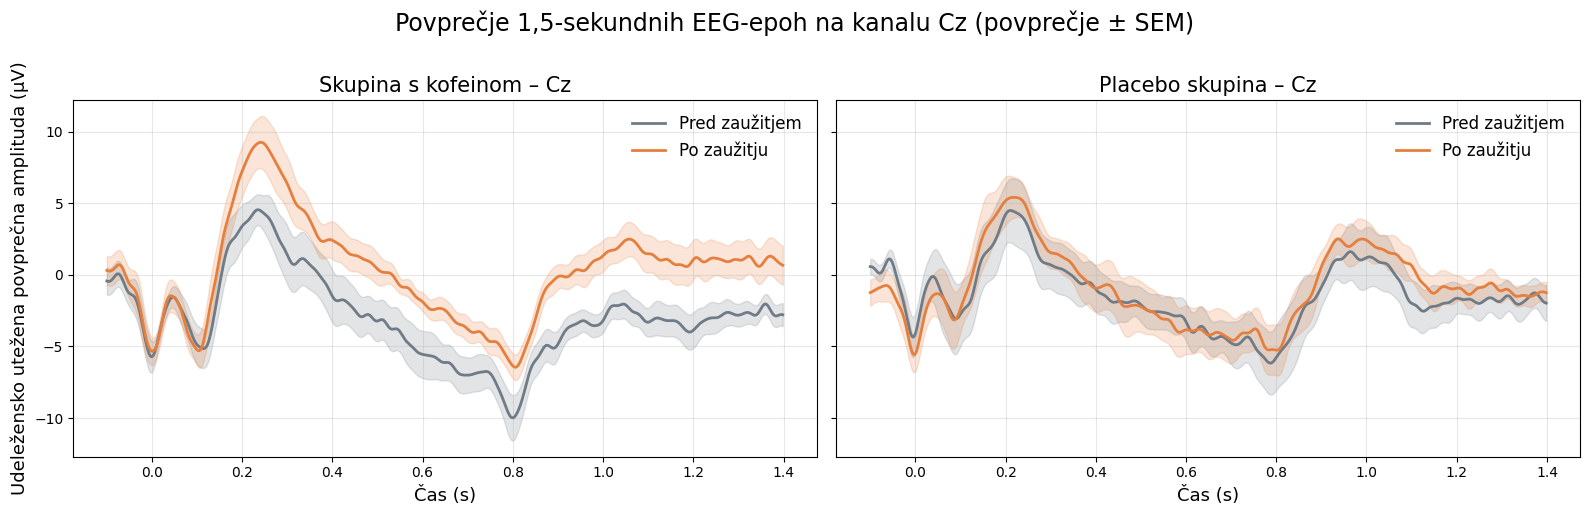

In [9]:
# Časovna os in indeks kanala Cz
first_eeg = ALLEEG[0, 0]
srate = float(np.squeeze(first_eeg["srate"]))
xmin = float(np.squeeze(first_eeg["xmin"]))
n_timepoints = first_eeg["data"].shape[1]
time = xmin + np.arange(n_timepoints) / srate

chanlocs = first_eeg["chanlocs"][0]
channel_names = [get_text(chanlocs[i], "labels") for i in range(len(chanlocs))]
cz_idx = channel_names.index("Cz")

# Za vsak par skupina–pogoj shranimo eno povprečno epoho na udeleženca
participant_means = {
    ("Caffeine", "Before"): [],
    ("Caffeine", "After"): [],
    ("Placebo", "Before"): [],
    ("Placebo", "After"): []
}

for i in range(ALLEEG.size):
    eeg = ALLEEG[0, i]

    group = get_text(eeg, "group")
    condition = get_text(eeg, "condition")
    eeg_data = eeg["data"]  # oblika: kanali × časovne točke × epohe

    key = (group, condition)

    if key not in participant_means:
        continue

    # Povprečje vseh epoh istega udeleženca na kanalu Cz
    mean_epoch = np.mean(eeg_data[cz_idx, :, :], axis=1)
    participant_means[key].append(mean_epoch)

# Izrišemo skupinski povprečji in standardno napako povprečja
colors = {"Before": "#6f7b86", "After": "#e67e3d"}
group_titles = {
    "Caffeine": "Skupina s kofeinom – Cz",
    "Placebo": "Placebo skupina – Cz"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, group in zip(axes, ["Caffeine", "Placebo"]):
    for condition in ["Before", "After"]:
        values = np.vstack(participant_means[(group, condition)])

        mean_signal = np.mean(values, axis=0)
        sem_signal = np.std(values, axis=0, ddof=1) / np.sqrt(values.shape[0])

        label = "Pred zaužitjem" if condition == "Before" else "Po zaužitju"

        ax.plot(
            time,
            mean_signal,
            color=colors[condition],
            linewidth=2,
            label=label
        )

        ax.fill_between(
            time,
            mean_signal - sem_signal,
            mean_signal + sem_signal,
            color=colors[condition],
            alpha=0.20
        )

    ax.set_title(group_titles[group], fontsize=15)
    ax.set_xlabel("Čas (s)", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, fontsize=12)

axes[0].set_ylabel("Udeležensko utežena povprečna amplituda (µV)", fontsize=13)

fig.suptitle(
    "Povprečje 1,5-sekundnih EEG-epoh na kanalu Cz (povprečje ± SEM)",
    fontsize=17,
    y=1.02
)

plt.tight_layout()
plt.show()

In [10]:
# Povzetek razpoložljivih EEG-zapisov
records = []

for i in range(ALLEEG.size):
    eeg = ALLEEG[0, i]
    eeg_data = eeg["data"]

    records.append({
        "udeleženec": get_text(eeg, "subject"),
        "skupina": get_text(eeg, "group"),
        "pogoj": get_text(eeg, "condition"),
        "število_epoh": eeg_data.shape[2],
        "število_kanalov": eeg_data.shape[0],
        "število_časovnih_točk": eeg_data.shape[1]
    })

eda_df = pd.DataFrame(records)

# Preglednica sestave podatkov
summary = (
    eda_df
    .groupby(["skupina", "pogoj"])
    .agg(
        število_udeležencev=("udeleženec", "nunique"),
        skupno_število_epoh=("število_epoh", "sum"),
        povprečno_število_epoh_na_udeleženca=("število_epoh", "mean")
    )
    .reset_index()
)

summary

,skupina,pogoj,število_udeležencev,skupno_število_epoh,povprečno_število_epoh_na_udeleženca
0,Caffeine,After,11,1070,97.272727
1,Caffeine,Before,11,1081,98.272727
2,Placebo,After,8,798,99.750000
3,Placebo,Before,8,764,95.500000


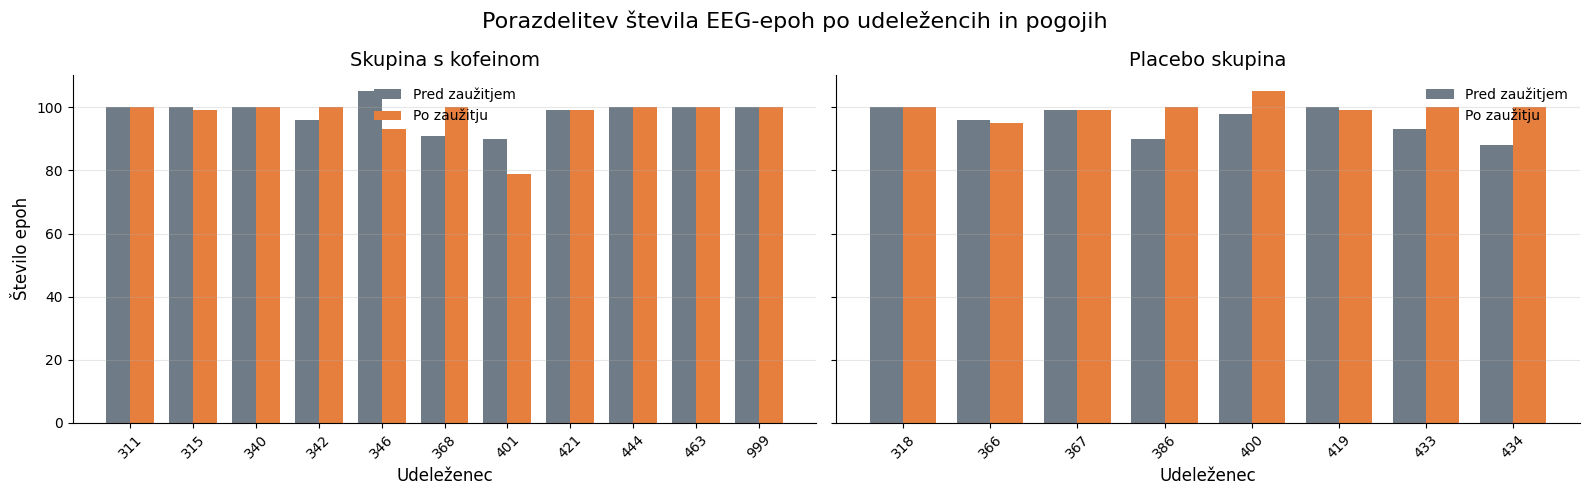

In [11]:
condition_order = ["Before", "After"]
group_order = ["Caffeine", "Placebo"]
colors = {"Before": "#6f7b86", "After": "#e67e3d"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True, facecolor="white")

for ax, group in zip(axes, group_order):
    group_data = eda_df[eda_df["skupina"] == group]

    pivot = (
        group_data
        .pivot(index="udeleženec", columns="pogoj", values="število_epoh")
        .reindex(columns=condition_order)
        .sort_index()
    )

    x = np.arange(len(pivot))
    width = 0.38

    ax.bar(
        x - width / 2,
        pivot["Before"],
        width,
        label="Pred zaužitjem",
        color=colors["Before"]
    )

    ax.bar(
        x + width / 2,
        pivot["After"],
        width,
        label="Po zaužitju",
        color=colors["After"]
    )

    title = "Skupina s kofeinom" if group == "Caffeine" else "Placebo skupina"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Udeleženec", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

axes[0].set_ylabel("Število epoh", fontsize=12)

fig.suptitle("Porazdelitev števila EEG-epoh po udeležencih in pogojih", fontsize=16)
plt.tight_layout()

plt.savefig(
    "porazdelitev_epoh_po_udelezencih.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

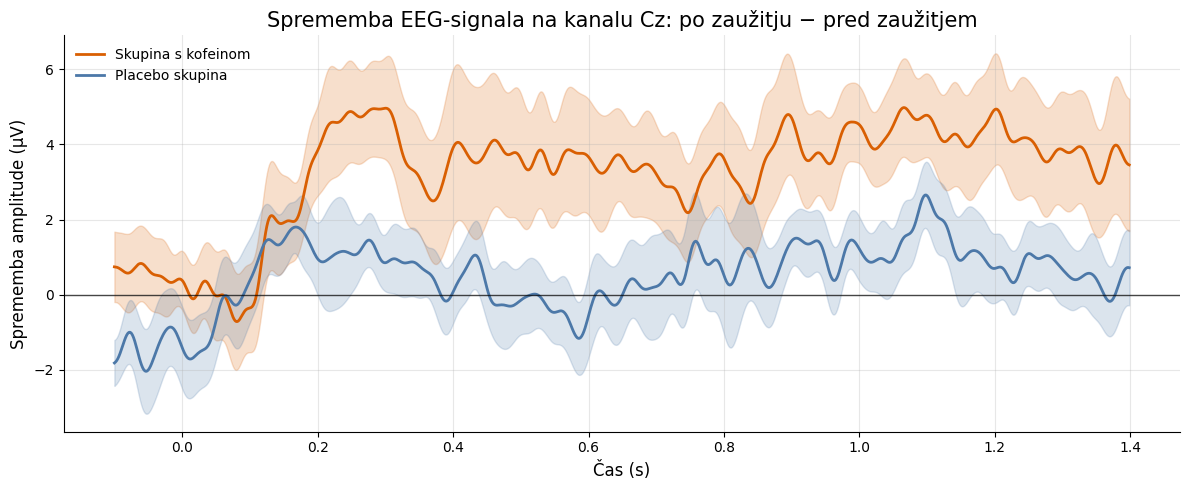

In [12]:
# Indeks kanala Cz
first_eeg = ALLEEG[0, 0]
chanlocs = first_eeg["chanlocs"][0]
channel_names = [get_text(chanlocs[i], "labels") for i in range(len(chanlocs))]
cz_idx = channel_names.index("Cz")

# Časovna os
srate = float(np.squeeze(first_eeg["srate"]))
xmin = float(np.squeeze(first_eeg["xmin"]))
n_timepoints = first_eeg["data"].shape[1]
time = xmin + np.arange(n_timepoints) / srate

# Povprečna epoha posameznega udeleženca za vsak pogoj
participant_means = {}

for i in range(ALLEEG.size):
    eeg = ALLEEG[0, i]

    group = get_text(eeg, "group")
    subject = get_text(eeg, "subject")
    condition = get_text(eeg, "condition")

    if group not in group_order or condition not in condition_order:
        continue

    mean_epoch = np.mean(eeg["data"][cz_idx, :, :], axis=1)
    participant_means[(group, subject, condition)] = mean_epoch

# Razlika After - Before za vsakega udeleženca
group_differences = {}

for group in group_order:
    subjects = sorted(
        {
            subject
            for current_group, subject, condition in participant_means.keys()
            if current_group == group
        }
    )

    differences = []

    for subject in subjects:
        before_key = (group, subject, "Before")
        after_key = (group, subject, "After")

        if before_key in participant_means and after_key in participant_means:
            difference = (
                participant_means[after_key] -
                participant_means[before_key]
            )
            differences.append(difference)

    group_differences[group] = np.vstack(differences)

fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")

difference_colors = {
    "Caffeine": "#d95f02",
    "Placebo": "#4c78a8"
}

for group in group_order:
    values = group_differences[group]

    mean_difference = np.mean(values, axis=0)
    sem_difference = np.std(values, axis=0, ddof=1) / np.sqrt(values.shape[0])

    label = "Skupina s kofeinom" if group == "Caffeine" else "Placebo skupina"

    ax.plot(
        time,
        mean_difference,
        color=difference_colors[group],
        linewidth=2,
        label=label
    )

    ax.fill_between(
        time,
        mean_difference - sem_difference,
        mean_difference + sem_difference,
        color=difference_colors[group],
        alpha=0.20
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.7)
ax.set_title("Sprememba EEG-signala na kanalu Cz: po zaužitju − pred zaužitjem", fontsize=15)
ax.set_xlabel("Čas (s)", fontsize=12)
ax.set_ylabel("Sprememba amplitude (µV)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "razlika_after_minus_before_cz.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## Primerjava EEG-kanalov med udelezenci v skupini s kofeinom

Na vsakem grafu je za posamezen kanal prikazana povprecna epoha vsakega udelezenca (povprecje vseh njegovih epoh). Tako se razlike med udelezenci ne mesajo z razlikami med posameznimi epohami. Zapis 318 je v podatkih oznacen kot placebo, zato ni del te primerjave.

Udelezenci v skupini s kofeinom: 311, 315, 340, 342, 346, 368, 401, 421, 444, 463, 999


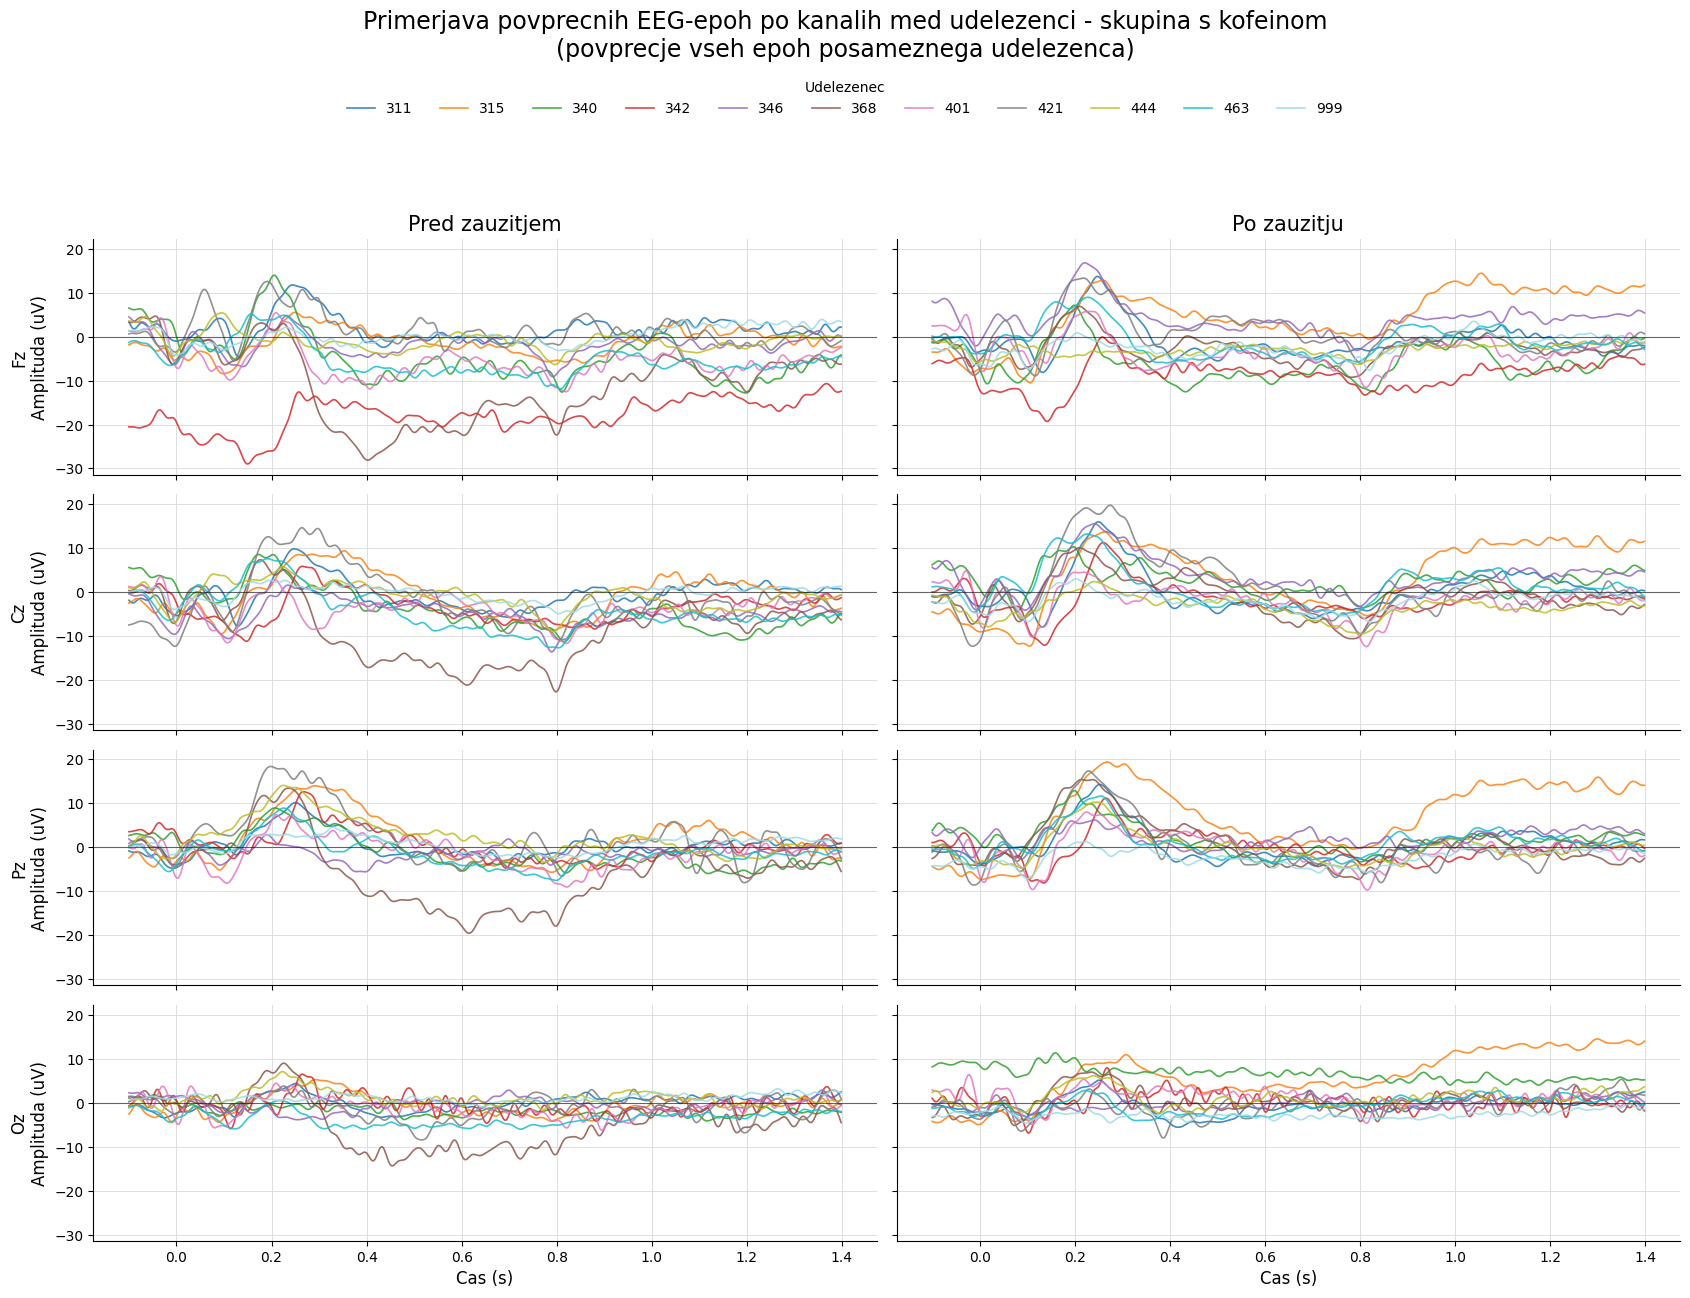

In [18]:
# Primerjava povprecnih EEG-epoh po kanalih med udelezenci skupine s kofeinom
comparison_group = "Caffeine"
conditions_to_plot = ["Before", "After"]
channels_to_plot = ["Fz", "Cz", "Pz", "Oz"]

# Za vsak par udelezenec-pogoj shranimo EEG zapis samo iz skupine s kofeinom.
caffeine_records = {}
for i in range(ALLEEG.size):
    eeg = ALLEEG[0, i]
    group = get_text(eeg, "group")
    subject = get_text(eeg, "subject")
    condition = get_text(eeg, "condition")

    if group == comparison_group and condition in conditions_to_plot:
        caffeine_records[(subject, condition)] = eeg

subjects = sorted(
    {subject for subject, condition in caffeine_records},
    key=lambda subject: int(subject)
)

missing_pairs = [
    (subject, condition)
    for subject in subjects
    for condition in conditions_to_plot
    if (subject, condition) not in caffeine_records
]

print(f"Udelezenci v skupini s kofeinom: {', '.join(subjects)}")
if missing_pairs:
    print(f"Manjkajoci zapisi: {missing_pairs}")

# Casovno os in indekse kanalov dolocimo iz prvega zapisa skupine s kofeinom.
first_eeg = next(iter(caffeine_records.values()))
srate = float(np.squeeze(first_eeg["srate"]))
xmin = float(np.squeeze(first_eeg["xmin"]))
n_timepoints = first_eeg["data"].shape[1]
time = xmin + np.arange(n_timepoints) / srate

chanlocs = first_eeg["chanlocs"][0]
channel_names = [get_text(chanlocs[i], "labels") for i in range(len(chanlocs))]
channel_indices = [channel_names.index(channel) for channel in channels_to_plot]

# Enaka barva predstavlja istega udelezenca v obeh pogojih in na vseh kanalih.
subject_colors = {
    subject: plt.cm.tab20(index / max(len(subjects) - 1, 1))
    for index, subject in enumerate(subjects)
}

fig, axes = plt.subplots(
    nrows=len(channels_to_plot),
    ncols=len(conditions_to_plot),
    figsize=(17, 13),
    sharex=True,
    sharey=True,
    facecolor="white"
)

for col_idx, condition in enumerate(conditions_to_plot):
    condition_label = "Pred zauzitjem" if condition == "Before" else "Po zauzitju"
    axes[0, col_idx].set_title(condition_label, fontsize=15)

    for row_idx, (channel_name, channel_idx) in enumerate(
        zip(channels_to_plot, channel_indices)
    ):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor("white")

        for subject in subjects:
            eeg = caffeine_records.get((subject, condition))
            if eeg is None:
                continue

            # Povprecje cez vse epohe: oblika podatkov je kanal x cas x epoha.
            mean_epoch = np.mean(eeg["data"][channel_idx, :, :], axis=1)
            ax.plot(
                time,
                mean_epoch,
                color=subject_colors[subject],
                linewidth=1.2,
                alpha=0.85,
                label=subject if row_idx == 0 and col_idx == 0 else None
            )

        ax.axhline(0, color="black", linewidth=0.8, alpha=0.55)
        ax.grid(True, color="#dddddd", linewidth=0.7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if col_idx == 0:
            ax.set_ylabel(f"{channel_name}\nAmplituda (uV)", fontsize=12)
        if row_idx == len(channels_to_plot) - 1:
            ax.set_xlabel("Cas (s)", fontsize=12)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Udelezenec",
    loc="upper center",
    ncol=min(len(subjects), 11),
    frameon=False,
    bbox_to_anchor=(0.5, 0.95),
    fontsize=10
)
fig.suptitle(
    "Primerjava povprecnih EEG-epoh po kanalih med udelezenci - skupina s kofeinom\n"
    "(povprecje vseh epoh posameznega udelezenca)",
    fontsize=17,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(
    "primerjava_kanalov_udelezenci_kofein.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    transparent=False
)
plt.show()

## Vsi kanali in razlike med udelezeni

Prvi graf prikaze spremembo `Po - Pred` na vseh kanalih. Drugi graf prikaze parno RMS-razliko vzorca spremembe med vsakim parom udelelezencev.

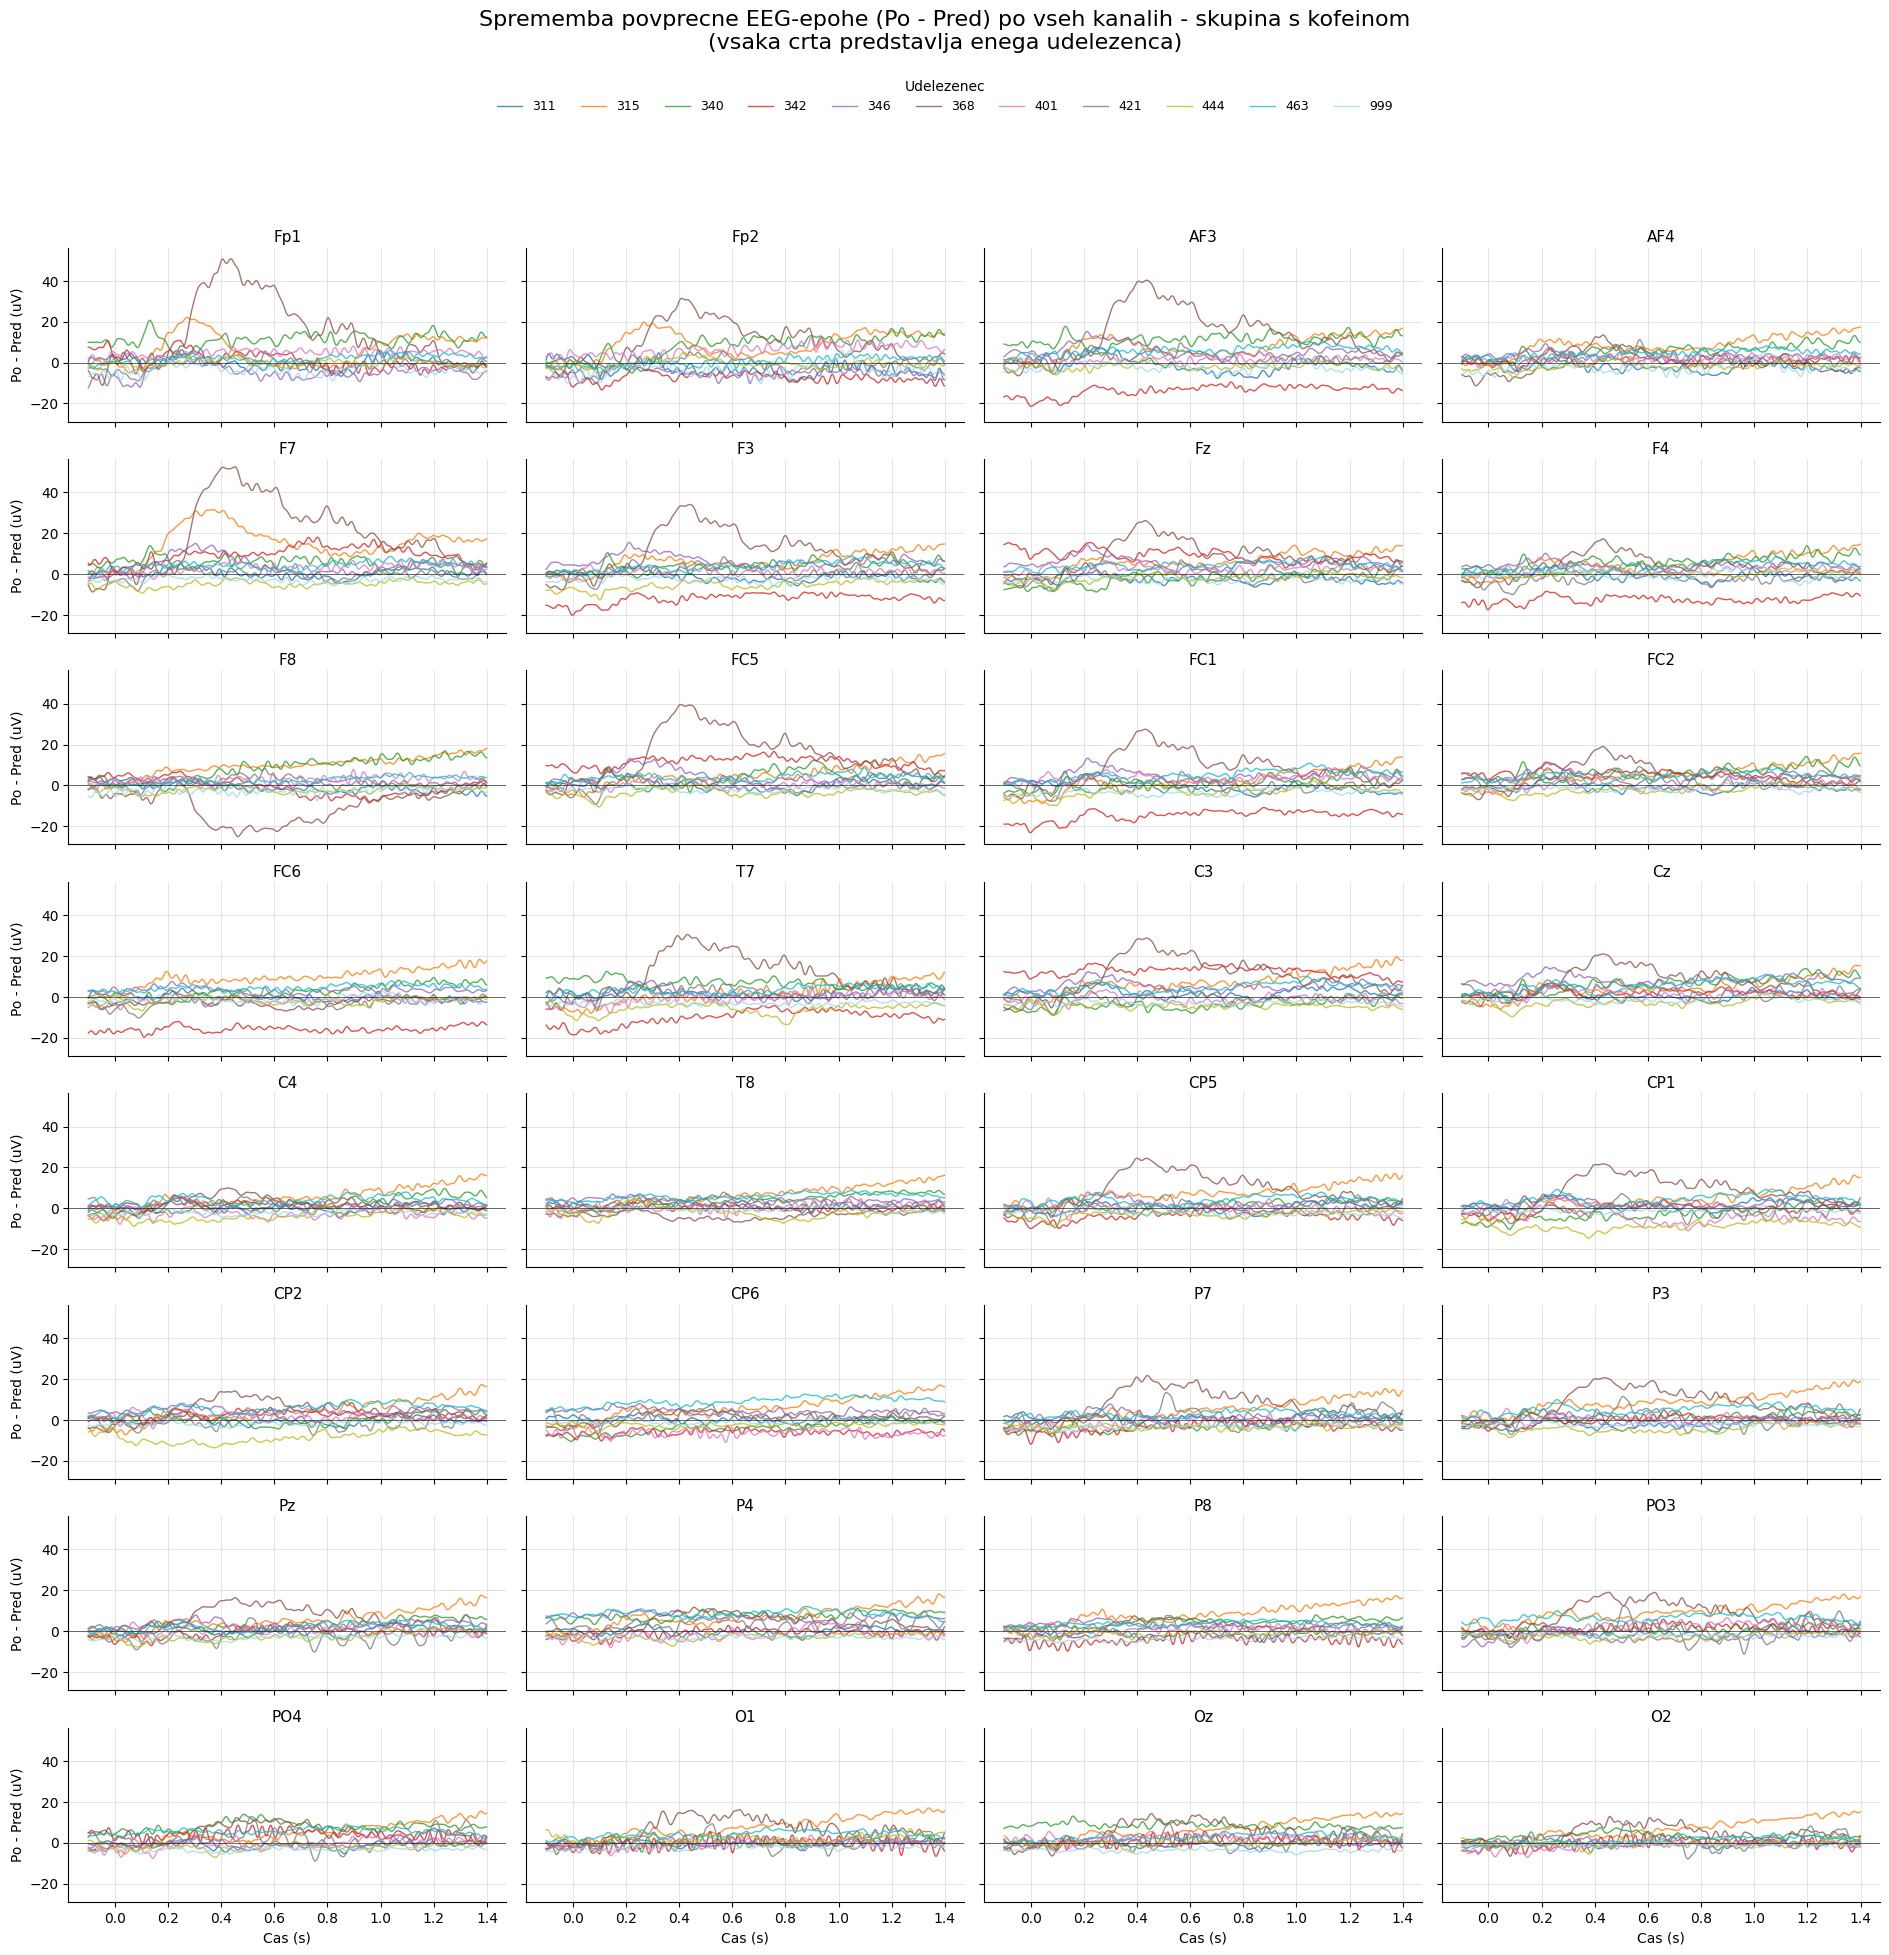

In [15]:
# Sprememba Po - Pred na vseh kanalih za vsakega udelelezenca v skupini s kofeinom.
# Zahteva zagon prejsnje celice, ki pripravi caffeine_records, subjects, time in subject_colors.
first_eeg = next(iter(caffeine_records.values()))
chanlocs = first_eeg["chanlocs"][0]
all_channel_names = [get_text(chanlocs[i], "labels") for i in range(len(chanlocs))]

n_columns = 4
n_rows = int(np.ceil(len(all_channel_names) / n_columns))
fig, axes = plt.subplots(
    n_rows, n_columns, figsize=(19, 2.45 * n_rows), sharex=True, sharey=True, facecolor="white"
)
axes = axes.ravel()

for channel_idx, (channel_name, ax) in enumerate(zip(all_channel_names, axes)):
    for subject in subjects:
        before_eeg = caffeine_records.get((subject, "Before"))
        after_eeg = caffeine_records.get((subject, "After"))
        if before_eeg is None or after_eeg is None:
            continue

        difference = (
            np.mean(after_eeg["data"][channel_idx, :, :], axis=1)
            - np.mean(before_eeg["data"][channel_idx, :, :], axis=1)
        )
        ax.plot(
            time, difference, color=subject_colors[subject],
            linewidth=1.0,
            alpha=0.80,
            label=subject if channel_idx == 0 else None
        )

    ax.axhline(0, color="black", linewidth=0.7, alpha=0.55)
    ax.grid(True, color="#dddddd", linewidth=0.55)
    ax.set_title(channel_name, fontsize=11, pad=4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[len(all_channel_names):]:
    ax.set_visible(False)
for ax in axes[-n_columns:]:
    if ax.get_visible():
        ax.set_xlabel("Cas (s)", fontsize=10)
for ax in axes[::n_columns]:
    ax.set_ylabel("Po - Pred (uV)", fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Udelezenec", loc="upper center",
    ncol=min(len(subjects), 11), frameon=False, bbox_to_anchor=(0.5, 0.965), fontsize=9
)
fig.suptitle(
    "Sprememba povprecne EEG-epohe (Po - Pred) po vseh kanalih - skupina s kofeinom\n"
    "(vsaka crta predstavlja enega udelezenca)",
    fontsize=16, y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(
    "razlika_pred_po_vsi_kanali_udelezenci_kofein.png", dpi=300,
    bbox_inches="tight", facecolor="white", transparent=False
)
plt.show()

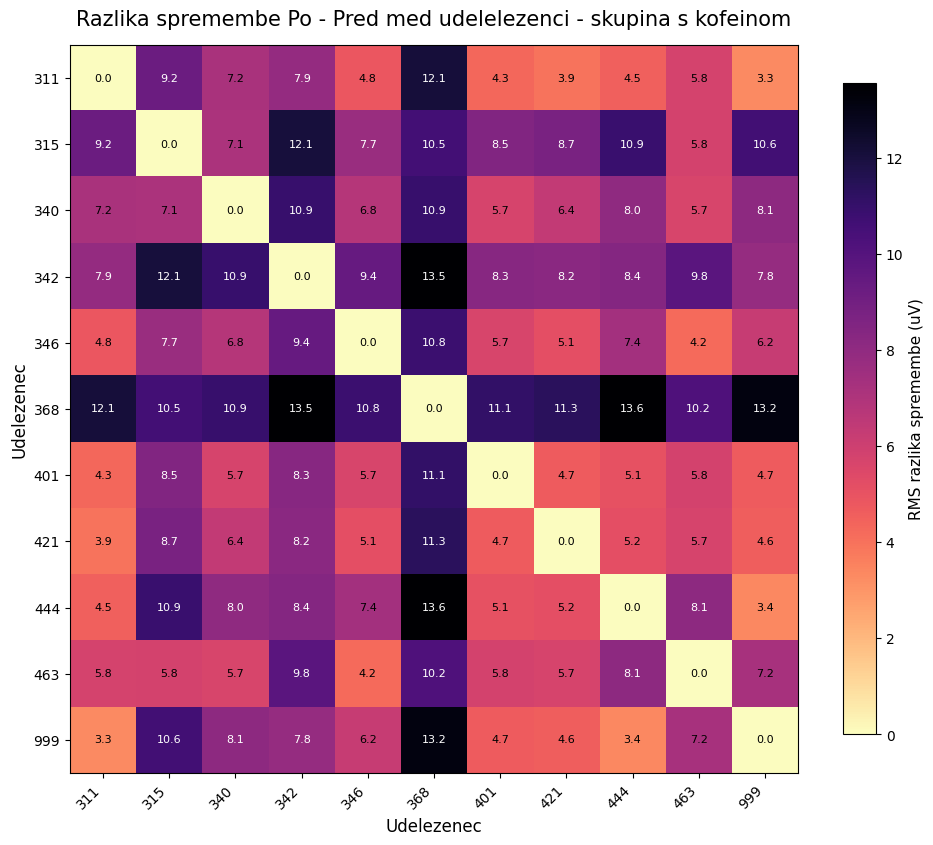

In [16]:
# Kako razlicna sta si dva udelelezenca v spremembi Po - Pred cez vse kanale in casovne tocke.
subject_change_vectors = {}
for subject in subjects:
    before_eeg = caffeine_records.get((subject, "Before"))
    after_eeg = caffeine_records.get((subject, "After"))
    if before_eeg is not None and after_eeg is not None:
        before_mean = np.mean(before_eeg["data"], axis=2)
        after_mean = np.mean(after_eeg["data"], axis=2)
        subject_change_vectors[subject] = (after_mean - before_mean).ravel()

distance_subjects = list(subject_change_vectors)
distance_matrix = np.zeros((len(distance_subjects), len(distance_subjects)))
for row_idx, subject_a in enumerate(distance_subjects):
    for col_idx, subject_b in enumerate(distance_subjects):
        distance_matrix[row_idx, col_idx] = np.sqrt(
            np.mean((subject_change_vectors[subject_a] - subject_change_vectors[subject_b]) ** 2)
        )

fig, ax = plt.subplots(figsize=(10, 8.5), facecolor="white")
image = ax.imshow(distance_matrix, cmap="magma_r", interpolation="nearest")
ax.set_xticks(np.arange(len(distance_subjects)))
ax.set_yticks(np.arange(len(distance_subjects)))
ax.set_xticklabels(distance_subjects, rotation=45, ha="right")
ax.set_yticklabels(distance_subjects)
ax.set_xlabel("Udelezenec", fontsize=12)
ax.set_ylabel("Udelezenec", fontsize=12)
ax.set_title("Razlika spremembe Po - Pred med udelelezenci - skupina s kofeinom", fontsize=15, pad=14)

for row_idx in range(len(distance_subjects)):
    for col_idx in range(len(distance_subjects)):
        value = distance_matrix[row_idx, col_idx]
        text_color = "white" if value > distance_matrix.max() * 0.55 else "black"
        ax.text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", color=text_color, fontsize=8)

colorbar = fig.colorbar(image, ax=ax, shrink=0.86)
colorbar.set_label("RMS razlika spremembe (uV)", fontsize=11)
plt.tight_layout()
plt.savefig(
    "matrika_razlik_med_udelezenci_kofein.png", dpi=300,
    bbox_inches="tight", facecolor="white", transparent=False
)
plt.show()

## Povprecje 1,5-sekundnih EEG-epoh na stirih kanalih

Prikaz vsebuje samo skupino s kofeinom. Za vsak kanal sta izracunani udelezensko utezeni povprecji pred in po zauzitju kofeina ter standardna napaka povprecja (SEM).

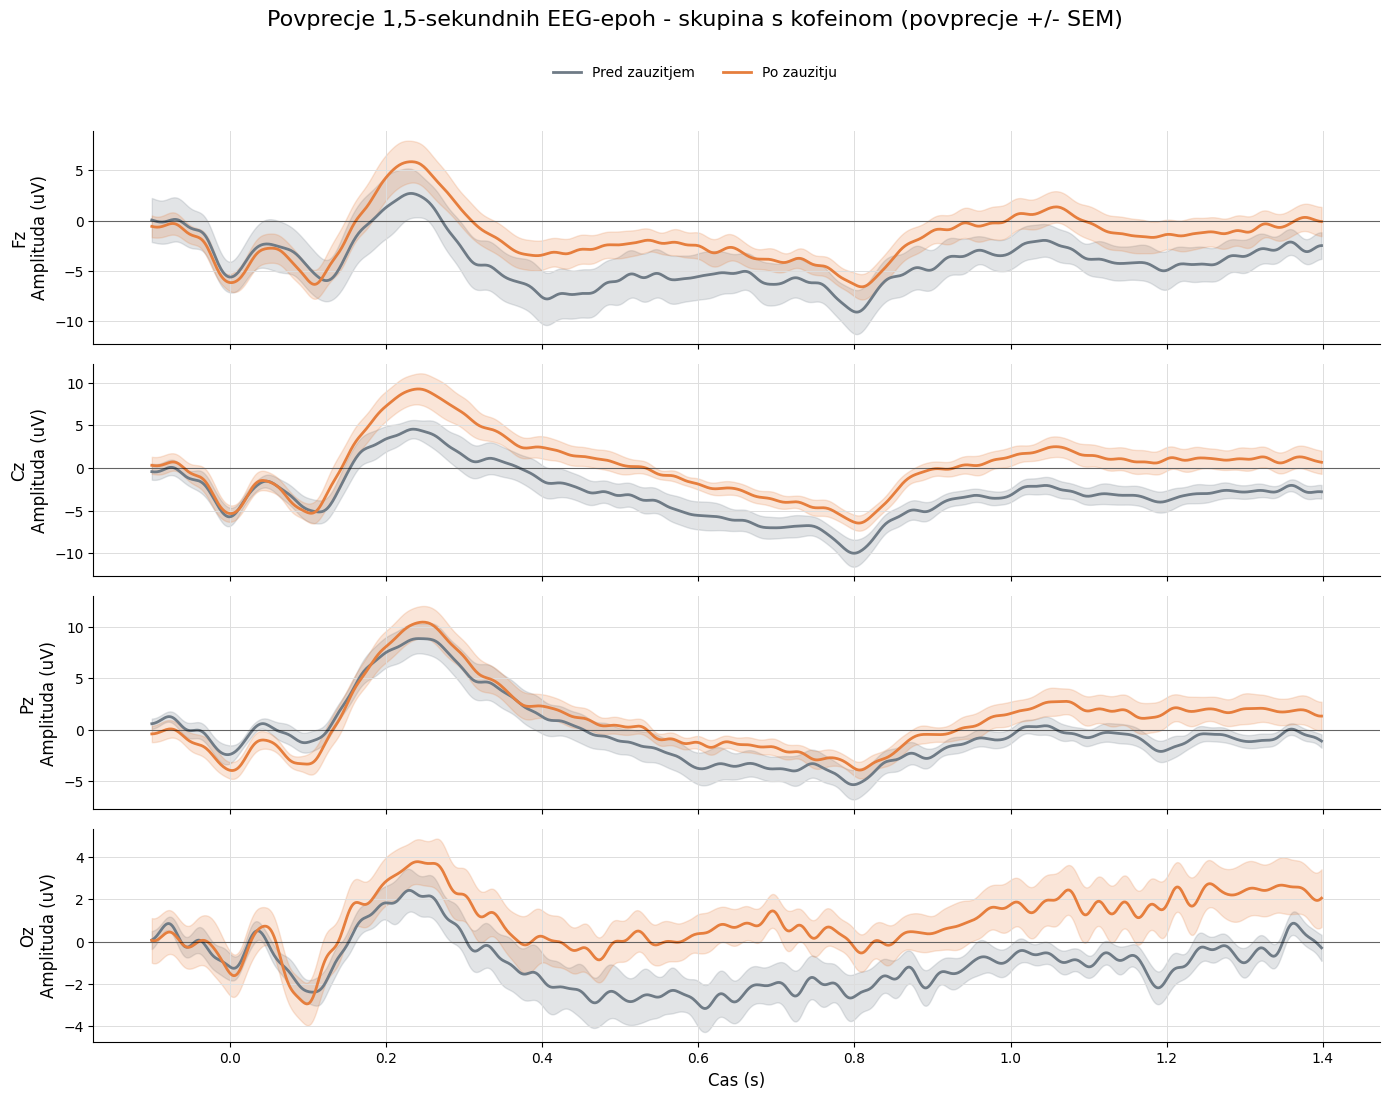

In [20]:
# Povprecje 1,5-sekundnih EEG-epoh na Fz, Cz, Pz in Oz - samo skupina s kofeinom.
comparison_group = "Caffeine"
conditions_to_plot = ["Before", "After"]
channels_to_plot = ["Fz", "Cz", "Pz", "Oz"]
epoch_duration_seconds = 1.5

caffeine_records = {}
for i in range(ALLEEG.size):
    eeg = ALLEEG[0, i]
    group = get_text(eeg, "group")
    subject = get_text(eeg, "subject")
    condition = get_text(eeg, "condition")
    if group == comparison_group and condition in conditions_to_plot:
        caffeine_records[(subject, condition)] = eeg

subjects = sorted({subject for subject, condition in caffeine_records}, key=int)
if not subjects:
    raise ValueError("Zapisi skupine s kofeinom niso bili najdeni.")

first_eeg = next(iter(caffeine_records.values()))
srate = float(np.squeeze(first_eeg["srate"]))
xmin = float(np.squeeze(first_eeg["xmin"]))
n_timepoints = first_eeg["data"].shape[1]
time = xmin + np.arange(n_timepoints) / srate
time_mask = time < xmin + epoch_duration_seconds
time_15s = time[time_mask]

chanlocs = first_eeg["chanlocs"][0]
channel_names = [get_text(chanlocs[i], "labels") for i in range(len(chanlocs))]
channel_indices = [channel_names.index(channel) for channel in channels_to_plot]
condition_colors = {"Before": "#6f7b86", "After": "#e67e3d"}
condition_labels = {"Before": "Pred zauzitjem", "After": "Po zauzitju"}

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True, facecolor="white")

for ax, channel_name, channel_idx in zip(axes, channels_to_plot, channel_indices):
    for condition in conditions_to_plot:
        participant_epochs = []
        for subject in subjects:
            eeg = caffeine_records.get((subject, condition))
            if eeg is not None:
                mean_epoch = np.mean(eeg["data"][channel_idx, time_mask, :], axis=1)
                participant_epochs.append(mean_epoch)

        values = np.vstack(participant_epochs)
        mean_signal = np.mean(values, axis=0)
        sem_signal = np.std(values, axis=0, ddof=1) / np.sqrt(values.shape[0])

        ax.plot(
            time_15s, mean_signal, color=condition_colors[condition], linewidth=2,
            label=condition_labels[condition]
        )
        ax.fill_between(
            time_15s, mean_signal - sem_signal, mean_signal + sem_signal,
            color=condition_colors[condition], alpha=0.20
        )

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.55)
    ax.set_ylabel(f"{channel_name}\nAmplituda (uV)", fontsize=12)
    ax.grid(True, color="#dddddd", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Cas (s)", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.955))
fig.suptitle(
    "Povprecje 1,5-sekundnih EEG-epoh - skupina s kofeinom (povprecje +/- SEM)",
    fontsize=16, y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(
    "povprecje_15s_epoh_4_kanali_kofein.png", dpi=300, bbox_inches="tight",
    facecolor="white", transparent=False
)
plt.show()